# Home advantage analysis

## Objective 
In this notebook I want to dive deeper into Home Advantage analysis. I want to investigate whether football clubs perform significantlt better at home and how this differs between clubs and leagues

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import helpers as hp
import matplotlib.pyplot as plt

In [2]:
team_stats = pd.read_csv("team_stats.csv")

In [3]:
team_stats.head()

,Club,League,Season,D,L,W,GF_home,GA_home,GF_away,GA_away,...,GA,D_home,L_home,W_home,D_away,L_away,W_away,home_winrate,away_winrate,home_advantage
0,1. FC Kaiserslautern,Germany 1. Bundesliga,2010/2011,7,14,13,25,19,23,32,...,51,6,5,6,1,9,7,0.352941,0.411765,-0.058824
1,1. FC Kaiserslautern,Germany 1. Bundesliga,2011/2012,11,19,4,12,28,12,26,...,54,5,10,2,6,9,2,0.117647,0.117647,0.000000
2,1. FC Köln,Germany 1. Bundesliga,2008/2009,6,17,11,14,25,21,25,...,50,5,8,4,1,9,7,0.235294,0.411765,-0.176471
3,1. FC Köln,Germany 1. Bundesliga,2009/2010,11,14,9,18,29,15,13,...,42,6,8,3,5,6,6,0.176471,0.352941,-0.176471
4,1. FC Köln,Germany 1. Bundesliga,2010/2011,5,16,13,30,21,17,41,...,62,2,4,11,3,12,2,0.647059,0.117647,0.529412


In [4]:
team_stats["home_advantage"].describe()

count    1478.000000
mean        0.171070
std         0.157623
min        -0.666667
25%         0.058824
50%         0.166667
75%         0.266667
max         0.736842
Name: home_advantage, dtype: float64

Distribution of home advantage for every team and every season 

Text(0, 0.5, 'Frequency')

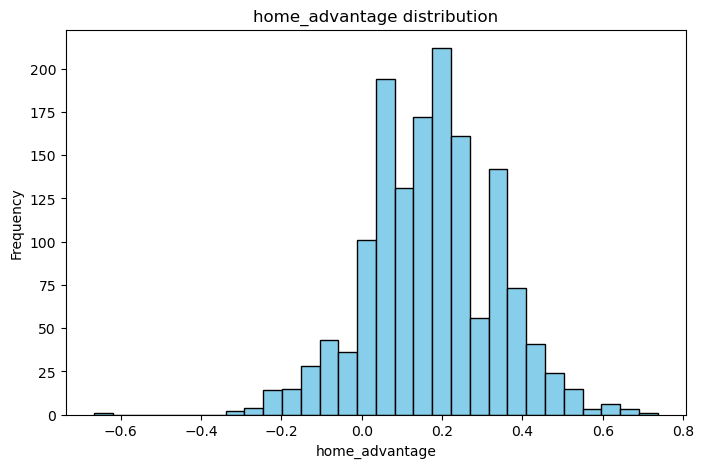

In [5]:
plt.figure(figsize=(8,5))
plt.hist(team_stats["home_advantage"], bins=30, edgecolor='black', color='skyblue')
plt.title('home_advantage distribution')
plt.xlabel('home_advantage')
plt.ylabel('Frequency')

But this data is a bit unfair. There are teams that play 1 season and they are too bad for the league. There's also teams, who "have one hit wonder" seasons. We should eliminate teams, who played less then 4 seasons from our analysis, so we'll have to deal only with teams that have enough data to make some assumptions. First of all we'll have to create new df for teams with 4+ seasons of data.

In [6]:
four_seasons = (team_stats['Club'].value_counts()>=4)

In [7]:
four_seasons = four_seasons[four_seasons == True]

In [8]:
team_stats_filtered = team_stats[team_stats["Club"].isin(four_seasons.index)]

In [9]:
team_stats_filtered["home_advantage"].describe()

count    1298.000000
mean        0.177434
std         0.157342
min        -0.333333
25%         0.058824
50%         0.176471
75%         0.294118
max         0.736842
Name: home_advantage, dtype: float64

Removed clubs with fewer seasons, and built histogram to see if there's some noticable changes. As we can see - new histogram still holds some extreme values, even though not as extreme as there were in the previous one

Text(0, 0.5, 'Frequency')

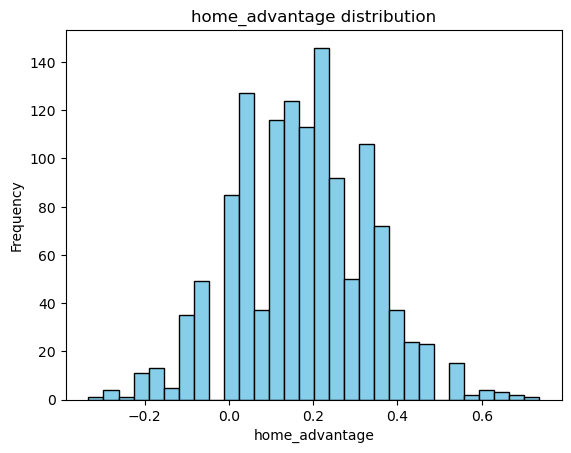

In [10]:
plt.hist(team_stats_filtered["home_advantage"], bins=30, edgecolor='black', color='skyblue')
plt.title('home_advantage distribution')
plt.xlabel('home_advantage')
plt.ylabel('Frequency')

Now we'll just have to groupby teams by seasons, so we'll see home_advantage grouped for all the seasons. The reason for it is quite simple - teams can have exceptional seasons or qutie bad seasons.

In [11]:
club_home_advantage = team_stats_filtered[["Club","home_advantage"]]

In [12]:
club_home_advantage.head()

,Club,home_advantage
2,1. FC Köln,-0.176471
3,1. FC Köln,-0.176471
4,1. FC Köln,0.529412
5,1. FC Köln,0.117647
6,1. FC Köln,-0.058824


In [13]:
club_home_advantage = club_home_advantage.groupby("Club")["home_advantage"].mean()

In [14]:
club_home_advantage = club_home_advantage.to_frame().reset_index()

In [15]:
club_home_advantage["home_advantage"].describe()

count    194.000000
mean       0.174681
std        0.073168
min       -0.053333
25%        0.128676
50%        0.176471
75%        0.227347
max        0.415205
Name: home_advantage, dtype: float64

In [16]:
club_home_advantage.groupby("Club")["home_advantage"].mean().nsmallest(15)

Club
Podbeskidzie Bielsko-Biała     -0.053333
Hamilton Academical FC         -0.042105
Inverness Caledonian Thistle    0.000000
Hibernian                       0.008772
Aston Villa                     0.026316
FC Zürich                       0.026552
Chievo Verona                   0.032895
1. FC Köln                      0.039216
Racing Santander                0.039474
AS Nancy-Lorraine               0.042105
Rangers                         0.052632
St. Mirren                      0.052632
St. Johnstone FC                0.059315
Real Betis Balompié             0.063158
Wigan Athletic                  0.063158
Name: home_advantage, dtype: float64

In [17]:
club_home_advantage.groupby("Club")["home_advantage"].mean().nlargest(15)

Club
Catania                   0.415205
Manchester City           0.335526
SC Bastia                 0.328947
RCD Mallorca              0.326316
Jagiellonia Białystok     0.325000
Palermo                   0.323308
Villarreal CF             0.315789
Valenciennes FC           0.289474
Fulham                    0.289474
SC Braga                  0.289216
KV Kortrijk               0.288675
Sevilla FC                0.282895
Genoa                     0.278874
FC Sochaux-Montbéliard    0.271930
Real Sociedad             0.263158
Name: home_advantage, dtype: float64

Text(0, 0.5, 'Frequency')

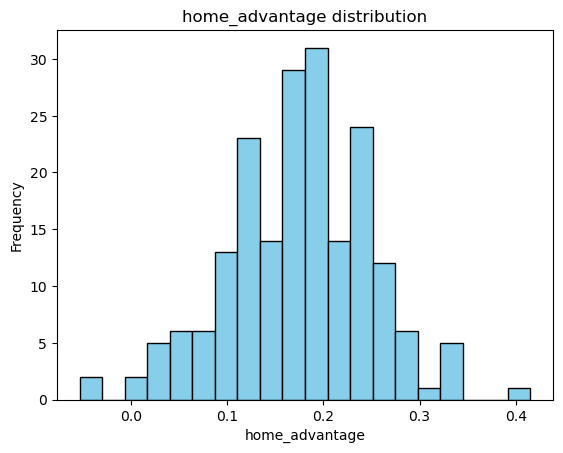

In [18]:
plt.hist(club_home_advantage["home_advantage"], bins=20, edgecolor='black', color='skyblue')
plt.title('home_advantage distribution')
plt.xlabel('home_advantage')
plt.ylabel('Frequency')

As we can see -  most clubs gather around 10 to 25 % better results at home with an average of ~17%. We've managed to remove clear outliers from our study. Standart deviation was 0.157, and now only 0.07 - that is more then a significant change. Extreme values in our first try was teams:
1. who perform bad and got relegated to lower division
2. who had significant season
3. by coincidence(meaning it just happens sometimes that you lose some games at home and away you perform better)

Through first filtration we've removed weak teams who out of 8 seasons managed to spend in top flight only 3 or less years. But this operation have made no impact, cause there was still teams with exceptionally good and bad seasons. So we'll have to find the mean for all teams all seasons.

Through second filtration we've removed any significant season chances by grouping home advantage and finding the mean out of this values. That made us a lot more confident in the data. We have almost no extreme values. The couple we still have will be object of further investigation.

The distribution appears approximately bell-shaped.

## Home advantage per league

The previous analysis showed that clubs generally benefit from playing at home. The next question is whether this advantage is similar across different leagues.

In [19]:
team_stats_filtered.head()

,Club,League,Season,D,L,W,GF_home,GA_home,GF_away,GA_away,...,GA,D_home,L_home,W_home,D_away,L_away,W_away,home_winrate,away_winrate,home_advantage
2,1. FC Köln,Germany 1. Bundesliga,2008/2009,6,17,11,14,25,21,25,...,50,5,8,4,1,9,7,0.235294,0.411765,-0.176471
3,1. FC Köln,Germany 1. Bundesliga,2009/2010,11,14,9,18,29,15,13,...,42,6,8,3,5,6,6,0.176471,0.352941,-0.176471
4,1. FC Köln,Germany 1. Bundesliga,2010/2011,5,16,13,30,21,17,41,...,62,2,4,11,3,12,2,0.647059,0.117647,0.529412
5,1. FC Köln,Germany 1. Bundesliga,2011/2012,6,20,8,20,29,19,46,...,75,4,8,5,2,12,3,0.294118,0.176471,0.117647
6,1. FC Köln,Germany 1. Bundesliga,2014/2015,13,12,9,18,17,16,23,...,40,9,4,4,4,8,5,0.235294,0.294118,-0.058824


In [20]:
league_home_advantage = team_stats_filtered[["Club","League","home_advantage"]]

In [21]:
league_home_advantage = league_home_advantage.groupby(["Club","League"])["home_advantage"].mean().reset_index()

In [22]:
league_home_advantage["home_advantage"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 194 entries, 0 to 193
Series name: home_advantage
Non-Null Count  Dtype  
--------------  -----  
194 non-null    float64
dtypes: float64(1)
memory usage: 1.6 KB


In [23]:
league_home_advantage["home_advantage"].describe()

count    194.000000
mean       0.174681
std        0.073168
min       -0.053333
25%        0.128676
50%        0.176471
75%        0.227347
max        0.415205
Name: home_advantage, dtype: float64

In [24]:
league_home_advantage.groupby("League")["home_advantage"].describe()

,count,mean,std,min,25%,50%,75%,max
League,,,,,,,,
Belgium Jupiler League,16.0,0.188739,0.062808,0.077111,0.153046,0.200730,0.239976,0.288675
England Premier League,21.0,0.177703,0.072036,0.026316,0.142857,0.164474,0.210526,0.335526
France Ligue 1,21.0,0.183011,0.072254,0.042105,0.126316,0.190789,0.236842,0.328947
Germany 1. Bundesliga,18.0,0.155910,0.056563,0.039216,0.125000,0.138480,0.184611,0.242647
Italy Serie A,19.0,0.211673,0.080390,0.032895,0.178954,0.210526,0.240758,0.415205
Netherlands Eredivisie,20.0,0.190756,0.041990,0.110294,0.166492,0.183824,0.235294,0.257353
Poland Ekstraklasa,17.0,0.168912,0.079687,-0.053333,0.133333,0.166667,0.208333,0.325000
Portugal Liga ZON Sagres,15.0,0.150641,0.056341,0.080000,0.112255,0.150980,0.183088,0.289216
Scotland Premier League,13.0,0.082217,0.075702,-0.042105,0.052632,0.065899,0.111842,0.233083


As we can see after we've described home_advantage for each league, there are some leagues with  not enough data to form reasonable conclussion. For example Swiss league has only 10 teams to make conclussions on. But nevertheless - their mean and std not too far off from average for clubs in all leagues. 

Another observation - number of teams with 4+ seasons spent in top flight is similair to the number of allowed teams in 1 season 1 league. ie germany really has 18 teams in top flight, england is really close with 21, italy with 19 - the same. Only Spain and France has a bit more then usual, but there can be a lot of reasons for this. Maybe we'll later investigate it.

We can also see that there's unusually low mean for Scotland Premier League. It means(no put intended) that there's a lot less difference at where do team play on average for teams playing this league. Compared to overall mean it is two times lower. Maybe there are dominant teams(Celtic and Rangers) that do not care where to play against much weaker opponents. I remember that both those teams were really good both at home and away winrate in my simple_data_analysis.ipynb notebook. We'll have to check all the teams in this league to understand what's going on

In [25]:
league_home_advantage.groupby("League")["home_advantage"].std()

League
Belgium Jupiler League      0.062808
England Premier League      0.072036
France Ligue 1              0.072254
Germany 1. Bundesliga       0.056563
Italy Serie A               0.080390
Netherlands Eredivisie      0.041990
Poland Ekstraklasa          0.079687
Portugal Liga ZON Sagres    0.056341
Scotland Premier League     0.075702
Spain LIGA BBVA             0.074850
Switzerland Super League    0.063320
Name: home_advantage, dtype: float64

<Axes: title={'center': 'home_advantage'}, ylabel='[League]'>

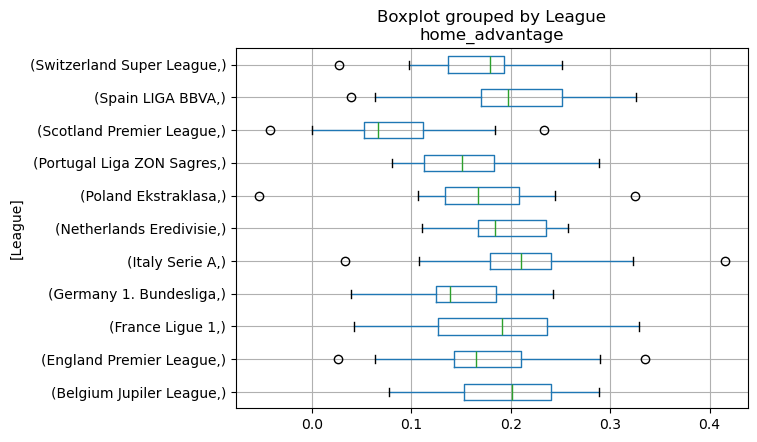

In [26]:
league_home_advantage.boxplot(column = ["home_advantage"], by = ["League"], vert = False,layout=(1,1))

Based on home advantage boxplot for leagues we can come to several conclusions:
1. Poland, Netherlands and Switzerland appear to have more compact distribution. This may be related to the relatively small number of clubs included in the analysis, although this would require further investigation.
2. Several leagues, particularly Scotland, Poland and Italy, contain clubs that are identified as potential outliers according to the boxplot. These clubs differ substantially from the rest of the clubs within their respective leagues.
3. There is more variability in home advatage between clubs in Spain and France, to lesser extent in Italy and England.  

## Outliers
My hypothesis is that outliers represent clubs with unusual home performance.

In [27]:
italian_league_stats = league_home_advantage[league_home_advantage["League"] == "Italy Serie A"]

In [28]:
italian_league_stats  = team_stats_filtered[team_stats_filtered["League"] == "Italy Serie A"]

In [29]:
italian_league_clubs = italian_league_stats.groupby("Club")["home_advantage"].mean().reset_index()

In [30]:
italian_league_clubs

,Club,home_advantage
0,Atalanta,0.235171
1,Bologna,0.107917
2,Cagliari,0.211779
3,Catania,0.415205
4,Chievo Verona,0.032895
5,Fiorentina,0.185759
6,Genoa,0.278874
7,Inter,0.172149
8,Juventus,0.138889
9,Lazio,0.205044


In [31]:
italian_league_clubs["home_advantage"].describe()

count    19.000000
mean      0.211673
std       0.080390
min       0.032895
25%       0.178954
50%       0.210526
75%       0.240758
max       0.415205
Name: home_advantage, dtype: float64

In [32]:
q1 = italian_league_clubs["home_advantage"].quantile(0.25)

In [33]:
q3 = italian_league_clubs["home_advantage"].quantile(0.75)

In [34]:
iqr = q3 - q1

In [35]:
lower = q1 - 1.5 * iqr

In [36]:
upper = q3 + 1.5 * iqr

In [37]:
print(q1,q3,iqr,lower,upper)

0.178953818369453 0.2407581453634085 0.061804326993955494 0.08624732787851977 0.3334646358543417


Now that we've found lower and upper bounds, we can find clubs that might be the outliers.

In [38]:
italian_league_clubs.loc[(italian_league_clubs['home_advantage'] > upper) | (italian_league_clubs['home_advantage'] < lower)]

,Club,home_advantage
3,Catania,0.415205
4,Chievo Verona,0.032895


There are two clubs on each side of our distribution, that can be considered an outliers.
The next step would be checking if their home advantage was always stable, or varied a lot season after season.

In [39]:
italian_league_stats[italian_league_stats["Club"] == "Catania"]["home_advantage"].mean()

np.float64(0.41520467836257313)

In [40]:
italian_league_stats[italian_league_stats["Club"] == "Catania"]["home_advantage"].std()

0.10448052132925054

In [41]:
italian_league_stats[italian_league_stats["Club"] == "Catania"]["home_advantage"].min()

0.3157894736842105

In [42]:
italian_league_stats[italian_league_stats["Club"] == "Catania"]["home_advantage"].max()

0.5263157894736843

In [43]:
italian_league_stats[italian_league_stats["Club"] == "Chievo Verona"]["home_advantage"].mean()

np.float64(0.03289473684210527)

In [44]:
italian_league_stats[italian_league_stats["Club"] == "Chievo Verona"]["home_advantage"].std()

0.1191498044491765

In [45]:
italian_league_stats[italian_league_stats["Club"] == "Chievo Verona"]["home_advantage"].min()

-0.1052631578947368

In [46]:
italian_league_stats[italian_league_stats["Club"] == "Chievo Verona"]["home_advantage"].max()

0.2631578947368421

In [47]:
catania = italian_league_stats[italian_league_stats["Club"] == "Catania"]

In [48]:
chievo_verona = italian_league_stats[italian_league_stats["Club"] == "Chievo Verona"]

In [49]:
mean_per_season = italian_league_stats.groupby("Season")["home_advantage"].mean()

In [50]:
mean_per_season

Season
2008/2009    0.286550
2009/2010    0.239766
2010/2011    0.213816
2011/2012    0.237115
2012/2013    0.188366
2013/2014    0.201238
2014/2015    0.112573
2015/2016    0.185965
Name: home_advantage, dtype: float64

In [51]:
italian_league_stats_no_catania = italian_league_stats[italian_league_stats["Club"] != "Catania"]

In [52]:
mean_per_season_no_catania = italian_league_stats_no_catania.groupby("Season")["home_advantage"].mean()

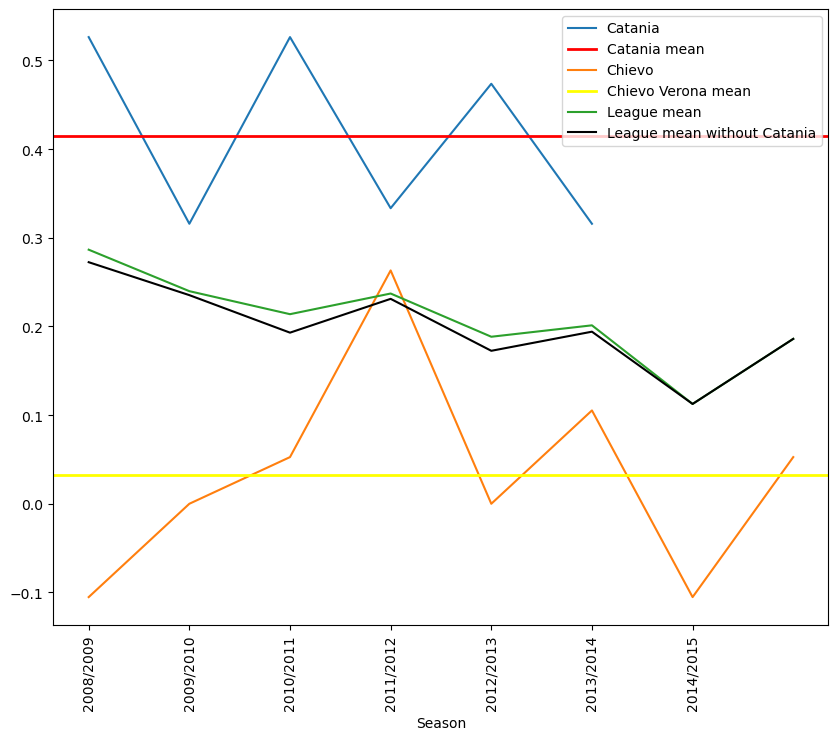

In [53]:
fig, ax = plt.subplots(figsize=(10, 8))

catania.plot(x="Season", y="home_advantage", ax=ax, kind="line", label ="Catania")
ax.axhline(catania["home_advantage"].mean(), color='red', linestyle='-', linewidth=2, label='Catania mean')

chievo_verona.plot(x="Season", y="home_advantage", ax=ax, kind="line", label ="Chievo")
ax.axhline(chievo_verona["home_advantage"].mean(), color='yellow', linestyle='-', linewidth=2, label='Chievo Verona mean')

mean_per_season.plot(x ="Season", y= "home_advantage", ax=ax, kind="line",label ="League mean")
mean_per_season_no_catania.plot(x ="Season", y= "home_advantage",color="black", ax=ax, kind="line",label ="League mean without Catania")
plt.xticks(rotation=90)
plt.legend()
plt.show()

In [54]:
difference = mean_per_season - mean_per_season_no_catania

In [55]:
difference

Season
2008/2009    0.014104
2009/2010    0.004472
2010/2011    0.020833
2011/2012    0.006014
2012/2013    0.015851
2013/2014    0.007159
2014/2015    0.000000
2015/2016    0.000000
Name: home_advantage, dtype: float64

Considering the data we've gathered - Catania is an obvious outlier and our hypothesis is correct for now. Throughout all of the seasons they've been in Serie A, they've managed to have a lot higher home advantage then all the other clubs on average. They've managed to play at home exceptionally better, then away. Even their worst season in terms of home advantage, after which they were relegated, had higher home advantage the the other clubs in the respective league.
Chievo Verona on the other hand is not that easy to read. They're realtively the same at home and away throughout all of the seasons. There are though season 2011/2012 that fits the narrative that clubs have an advantage at home, and there are two seasons where they were winning more away games. It can't be said that they're the outlier. 

## Conclusions
We've managed to discover that almost all the clubs have significant advantage in playing at home.
We've checked averages between leagues, inside leagues, searched for outliers. It is for now just a brief introduction into home advantage analysis, but there were certain conclusions that were made.


In [57]:
columns_for_correlation = [
    "W", "D", "L",
    "GF", "GA",
    "GF_home", "GA_home",
    "GF_away", "GA_away",
    "W_home", "W_away",
    "home_advantage"
]

In [58]:
correlation_matrix = team_stats[columns_for_correlation].corr()

In [59]:
correlation_matrix["home_advantage"].sort_values()

W_away           -0.336513
GA_home          -0.273187
GF_away          -0.163973
D                -0.107980
L                -0.070414
GA               -0.067589
GF                0.110433
GA_away           0.117115
W                 0.132059
GF_home           0.310817
W_home            0.518344
home_advantage    1.000000
Name: home_advantage, dtype: float64

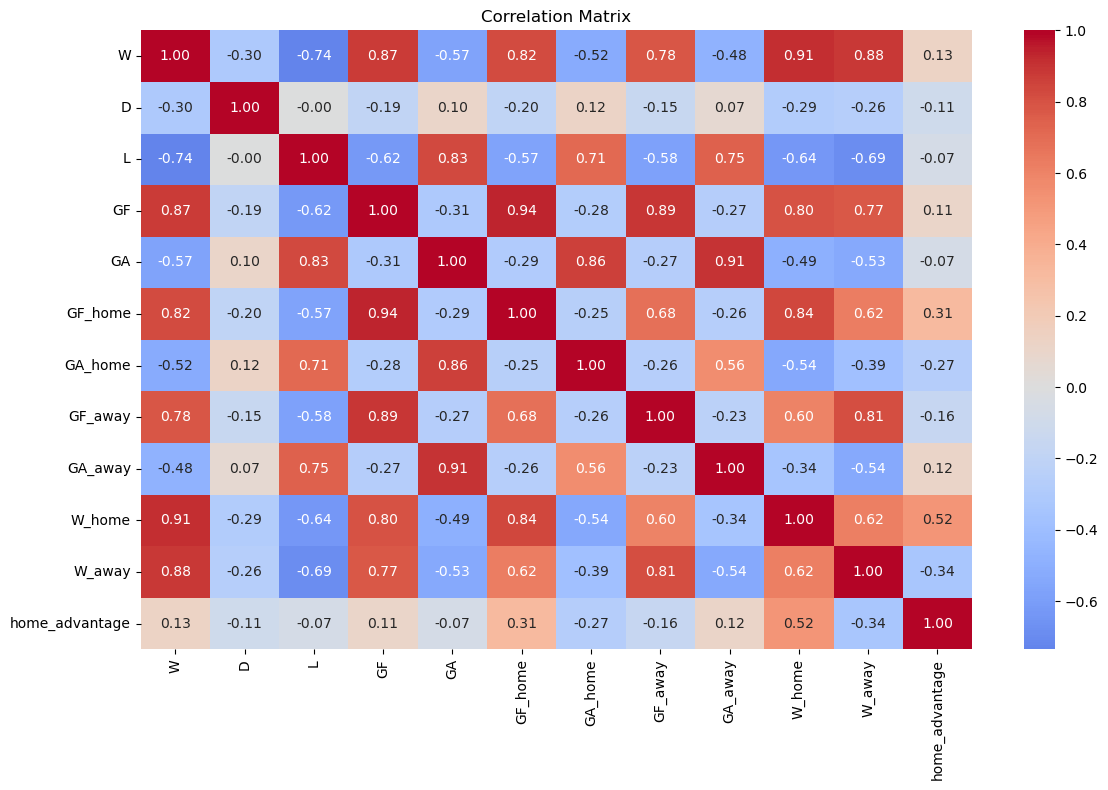

In [61]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [63]:
team_stats.select_dtypes(include = "number")

,D,L,W,GF_home,GA_home,GF_away,GA_away,GF,GA,D_home,L_home,W_home,D_away,L_away,W_away,home_winrate,away_winrate,home_advantage
0,7,14,13,25,19,23,32,48,51,6,5,6,1,9,7,0.352941,0.411765,-0.058824
1,11,19,4,12,28,12,26,24,54,5,10,2,6,9,2,0.117647,0.117647,0.000000
2,6,17,11,14,25,21,25,35,50,5,8,4,1,9,7,0.235294,0.411765,-0.176471
3,11,14,9,18,29,15,13,33,42,6,8,3,5,6,6,0.176471,0.352941,-0.176471
4,5,16,13,30,21,17,41,47,62,2,4,11,3,12,2,0.647059,0.117647,0.529412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1473,5,8,17,26,14,21,17,47,31,2,4,9,3,4,8,0.600000,0.533333,0.066667
1474,8,9,13,23,15,21,27,44,42,4,2,9,4,7,4,0.600000,0.266667,0.333333
1475,13,10,7,21,16,17,24,38,40,6,4,5,7,6,2,0.333333,0.133333,0.200000
1476,10,8,12,21,9,22,27,43,36,4,2,9,6,6,3,0.600000,0.200000,0.400000


In [64]:
team_stats.select_dtypes(include = "object")

,Club,League,Season
0,1. FC Kaiserslautern,Germany 1. Bundesliga,2010/2011
1,1. FC Kaiserslautern,Germany 1. Bundesliga,2011/2012
2,1. FC Köln,Germany 1. Bundesliga,2008/2009
3,1. FC Köln,Germany 1. Bundesliga,2009/2010
4,1. FC Köln,Germany 1. Bundesliga,2010/2011
...,...,...,...
1473,Śląsk Wrocław,Poland Ekstraklasa,2011/2012
1474,Śląsk Wrocław,Poland Ekstraklasa,2012/2013
1475,Śląsk Wrocław,Poland Ekstraklasa,2013/2014
1476,Śląsk Wrocław,Poland Ekstraklasa,2014/2015
